## Hw 1b: Experimental Analysis of a Shallow Neural Network

Import all necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch

from training_utils import run_experiment, plot_results, apply_augmentations, show_batch

### 1. Validation set
First 10,000 images of the training set for validation, the remaining 50,000 for training

In [2]:
train_df = pd.read_csv("fashion_mnist/fashion-mnist_train.csv")

labels_np = train_df.iloc[:, 0].astype(np.int64).values.copy()
images_np = train_df.iloc[:, 1:].astype(np.float32).values.copy()

X = torch.tensor(images_np, dtype=torch.float32) / 255.0
Y = torch.tensor(labels_np, dtype=torch.long)

X_valid, Y_valid = X[:10000], Y[:10000]
X_train, Y_train = X[10000:], Y[10000:]

X_train.shape, X_valid.shape

(torch.Size([50000, 784]), torch.Size([10000, 784]))

### 2. Learning rate selection
Hidden size 50, 500 epochs, new model for every learning rate. Same seed before each model so they all start from the same weights

In [3]:
epochs = 500
learning_rates = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]

lr_results = [run_experiment(X_train, Y_train, X_valid, Y_valid, learning_rate=lr, hidden_size=50, epochs=epochs) for lr in learning_rates]
lr_df = pd.DataFrame(lr_results)[["learning_rate", "train_loss", "valid_loss", "valid_acc"]]
lr_df

lr=1        hidden=50    aug=baseline   | train_loss 2.2598 | valid_loss 2.2867 | valid_acc 0.1114
lr=0.1      hidden=50    aug=baseline   | train_loss 0.3740 | valid_loss 0.4670 | valid_acc 0.8455
lr=0.01     hidden=50    aug=baseline   | train_loss 0.2073 | valid_loss 0.3453 | valid_acc 0.8813
lr=0.001    hidden=50    aug=baseline   | train_loss 0.3457 | valid_loss 0.3852 | valid_acc 0.8662
lr=0.0001   hidden=50    aug=baseline   | train_loss 0.6685 | valid_loss 0.6736 | valid_acc 0.7916
lr=1e-05    hidden=50    aug=baseline   | train_loss 1.8120 | valid_loss 1.8099 | valid_acc 0.6252


,learning_rate,train_loss,valid_loss,valid_acc
0,1.00000,2.259825,2.286667,0.1114
1,0.10000,0.373996,0.466976,0.8455
2,0.01000,0.207290,0.345323,0.8813
3,0.00100,0.345709,0.385195,0.8662
4,0.00010,0.668543,0.673571,0.7916
5,0.00001,1.812005,1.809860,0.6252


Interpolate between the two best learning rates. We rank them by validation loss instead of accuracy, it is smoother and also shows when a model starts overfitting

In [4]:
low = lr_df.nsmallest(2, "valid_loss")["learning_rate"].min()
new_lrs = [low * m for m in [2, 3, 5, 7]]
print("new learning rates:", new_lrs)

new_results = [run_experiment(X_train, Y_train, X_valid, Y_valid, learning_rate=lr, hidden_size=50, epochs=epochs) for lr in new_lrs]
lr_all_df = pd.concat([lr_df, pd.DataFrame(new_results)[lr_df.columns]])
lr_all_df = lr_all_df.sort_values("learning_rate").reset_index(drop=True)

best_lr = lr_all_df.loc[lr_all_df["valid_loss"].idxmin(), "learning_rate"]
print("best learning rate:", best_lr)
lr_all_df

new learning rates: [0.002, 0.003, 0.005, 0.007]
lr=0.002    hidden=50    aug=baseline   | train_loss 0.2976 | valid_loss 0.3598 | valid_acc 0.8757
lr=0.003    hidden=50    aug=baseline   | train_loss 0.2737 | valid_loss 0.3605 | valid_acc 0.8736
lr=0.005    hidden=50    aug=baseline   | train_loss 0.2514 | valid_loss 0.3654 | valid_acc 0.8718
lr=0.007    hidden=50    aug=baseline   | train_loss 0.2428 | valid_loss 0.3631 | valid_acc 0.8742
best learning rate: 0.01


,learning_rate,train_loss,valid_loss,valid_acc
0,0.00001,1.812005,1.809860,0.6252
1,0.00010,0.668543,0.673571,0.7916
2,0.00100,0.345709,0.385195,0.8662
3,0.00200,0.297603,0.359789,0.8757
4,0.00300,0.273671,0.360549,0.8736
5,0.00500,0.251436,0.365364,0.8718
6,0.00700,0.242807,0.363108,0.8742
7,0.01000,0.207290,0.345323,0.8813
8,0.10000,0.373996,0.466976,0.8455
9,1.00000,2.259825,2.286667,0.1114


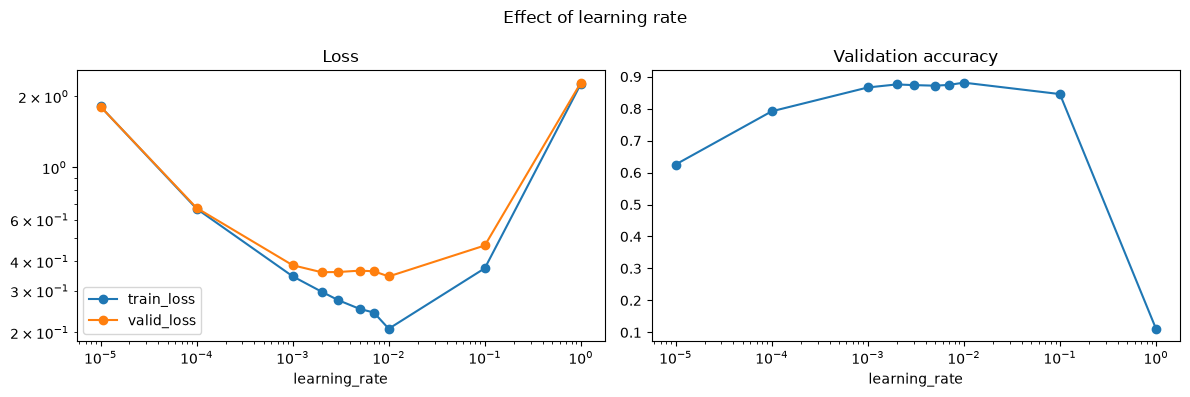

In [5]:
plot_results(lr_all_df, "learning_rate", log_x=True)

**Observations:** lr = 1 is way too big, the loss stays around 2.3 so the model is basically guessing (11% accuracy). 1e-4 and 1e-5 are too small and don't converge in 500 epochs. The best one is 0.01 (valid loss 0.345, 88.1% accuracy). Between 0.001 and 0.01 all the values are quite close, so in that range the exact learning rate doesn't change much. 0.01 is also the edge of what we interpolated, so something a bit higher like 0.02 could be slightly better but we didn't test it.

### 3. Effect of hidden layer size
Learning rate fixed to the best one from above

In [6]:
hidden_sizes = [10, 50, 100, 300, 1000, 2000]

hidden_results = [run_experiment(X_train, Y_train, X_valid, Y_valid, learning_rate=best_lr, hidden_size=h, epochs=epochs) for h in hidden_sizes]
hidden_df = pd.DataFrame(hidden_results)[["hidden_size", "train_loss", "valid_loss", "valid_acc"]]

best_hidden = int(hidden_df.loc[hidden_df["valid_loss"].idxmin(), "hidden_size"])
print("best hidden size:", best_hidden)
hidden_df

lr=0.01     hidden=10    aug=baseline   | train_loss 0.3338 | valid_loss 0.4113 | valid_acc 0.8582
lr=0.01     hidden=50    aug=baseline   | train_loss 0.2073 | valid_loss 0.3453 | valid_acc 0.8813
lr=0.01     hidden=100   aug=baseline   | train_loss 0.1740 | valid_loss 0.3479 | valid_acc 0.8824
lr=0.01     hidden=300   aug=baseline   | train_loss 0.1482 | valid_loss 0.4004 | valid_acc 0.8847
lr=0.01     hidden=1000  aug=baseline   | train_loss 0.1045 | valid_loss 0.4629 | valid_acc 0.8751
lr=0.01     hidden=2000  aug=baseline   | train_loss 0.1154 | valid_loss 0.4076 | valid_acc 0.8874
best hidden size: 50


,hidden_size,train_loss,valid_loss,valid_acc
0,10,0.333825,0.411259,0.8582
1,50,0.207290,0.345323,0.8813
2,100,0.174048,0.347882,0.8824
3,300,0.148245,0.400418,0.8847
4,1000,0.104485,0.462859,0.8751
5,2000,0.115392,0.407612,0.8874


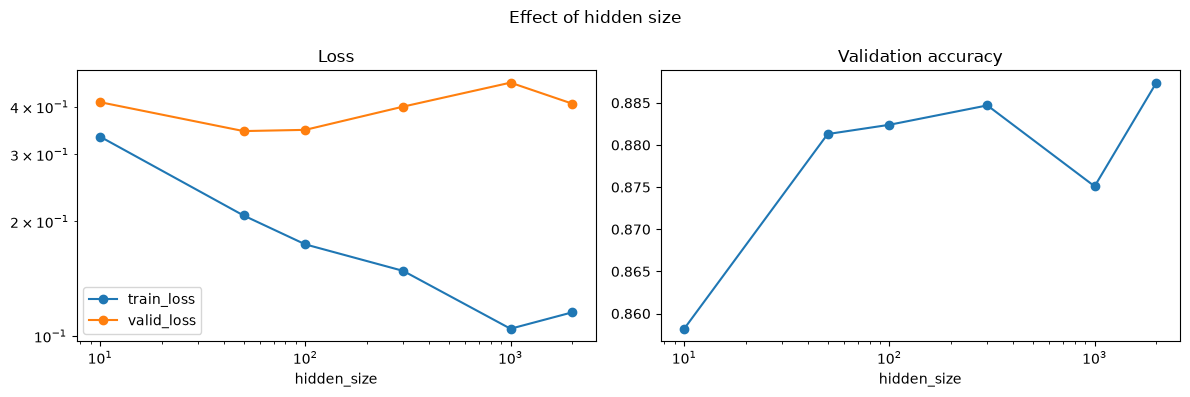

In [7]:
plot_results(hidden_df, "hidden_size", log_x=True)

**Observations:** Train loss keeps going down as the hidden layer gets bigger, since the model has more capacity. Validation loss is lowest at 50-100 and then gets worse, so the bigger networks are overfitting. Accuracy barely changes (85.8% to 88.7%). 2000 has the highest accuracy but a clearly worse validation loss, so we keep 50, which is also a much smaller model.

### 4. Visualize transformed images
First row: original images. Rows 2 to 4: mild, moderate and aggressive

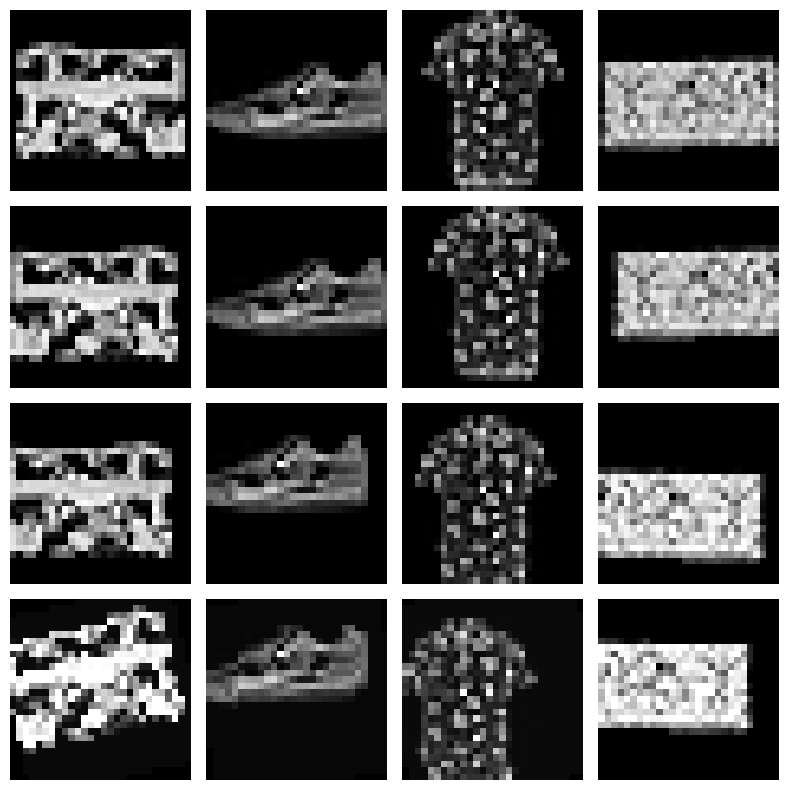

In [8]:
imgs = X_train[:4]

rows = [imgs]
for level in ["mild", "moderate", "aggressive"]:
    rows.append(torch.cat([apply_augmentations(img, level=level) for img in imgs]))

show_batch(torch.cat(rows).reshape(-1, 28, 28))

### 5. Effect of data augmentation
Best learning rate and hidden size from above. Only the training images are augmented, so the train loss of the augmented runs is measured on augmented images

In [9]:
aug_levels = [None, "mild", "moderate", "aggressive"]

aug_results = [run_experiment(X_train, Y_train, X_valid, Y_valid, learning_rate=best_lr, hidden_size=best_hidden, epochs=epochs, level=level) for level in aug_levels]
aug_df = pd.DataFrame(aug_results)[["augmentation", "train_loss", "valid_loss", "valid_acc"]]
aug_df

lr=0.01     hidden=50    aug=baseline   | train_loss 0.2073 | valid_loss 0.3453 | valid_acc 0.8813
lr=0.01     hidden=50    aug=mild       | train_loss 0.4610 | valid_loss 0.4193 | valid_acc 0.8549
lr=0.01     hidden=50    aug=moderate   | train_loss 0.5318 | valid_loss 0.4850 | valid_acc 0.8269
lr=0.01     hidden=50    aug=aggressive | train_loss 0.6816 | valid_loss 0.6034 | valid_acc 0.7787


,augmentation,train_loss,valid_loss,valid_acc
0,baseline,0.207290,0.345323,0.8813
1,mild,0.461020,0.419307,0.8549
2,moderate,0.531778,0.484999,0.8269
3,aggressive,0.681560,0.603369,0.7787


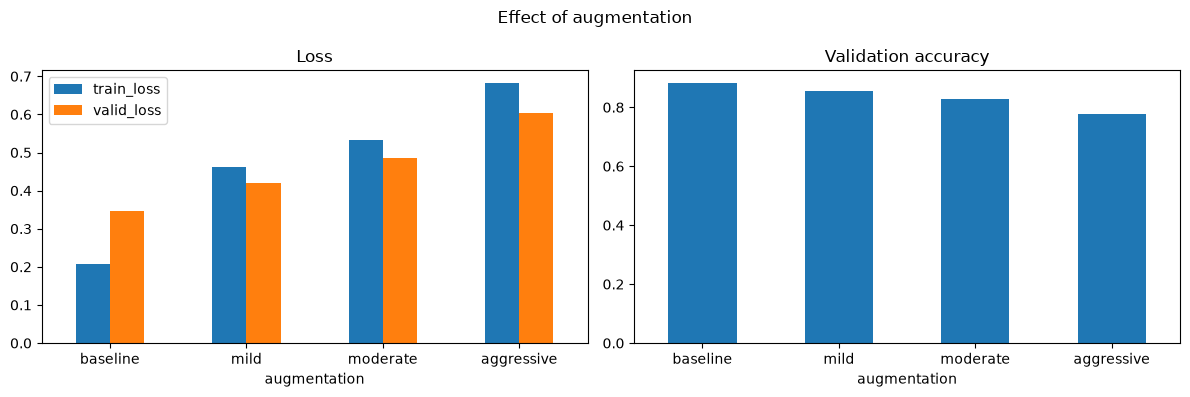

In [10]:
plot_results(aug_df, "augmentation", kind="bar")

**Observations:** Augmentation made the model worse here, and the stronger the augmentation the lower the validation accuracy (88.1% baseline vs 77.9% aggressive). Train loss goes up as expected because the augmented images are harder to fit. For the augmented runs the validation loss is even lower than the train loss, so the model is underfitting, not overfitting, and doesn't need the extra regularization. Also a fully connected network has no translation invariance, a 2 pixel shift is a completely different input for it, and the validation images are all centered. Augmentation would probably help more with a CNN or longer training.